In [2]:
# !git clone https://github.com/milki93/creditrust-rag-chatbot.git

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/creditrust-rag-chatbot/notebooks

/content/creditrust-rag-chatbot/notebooks


# Exploratory Data Analysis and Preprocessing for CFPB Complaints

This notebook performs EDA and data cleaning on the CFPB complaints dataset, focusing on five key products and preparing the data for downstream RAG/LLM tasks.

In [6]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load the Data

We load the raw complaints CSV into a DataFrame for analysis.

In [7]:
import pandas as pd

# Load the CFPB complaint dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Week 6/complaints.csv')

# Display the first few rows
df.head()

/tmp/ipython-input-7-2357709793.py:4: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Week 6/complaints.csv')


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


## Initial Data Exploration

Let's check the structure, missing values, and some sample narratives.

In [8]:
# Check the structure and info
df.info()

# Check for missing values
df.isnull().sum()

# Show unique values for key columns
print("Unique products:", df['Product'].unique())
print("Sample narratives:", df['Consumer complaint narrative'].dropna().sample(3).values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

## Distribution of Complaints Across Products

Visualize the number of complaints for each product.

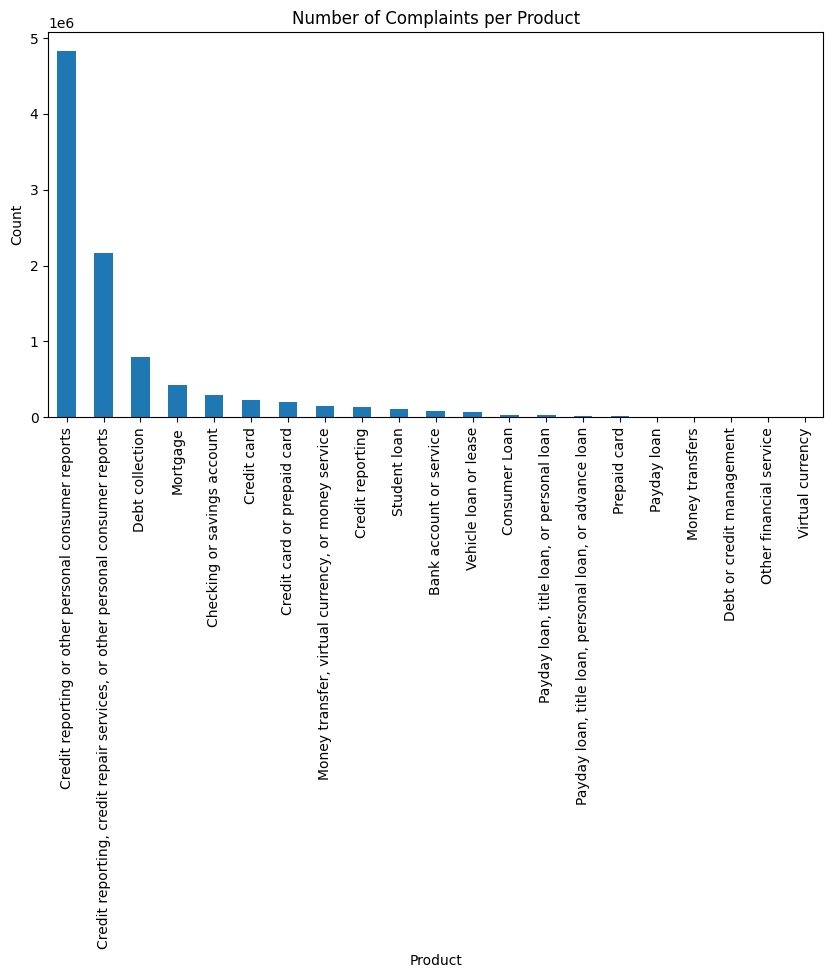

In [9]:
import matplotlib.pyplot as plt

# Count complaints per product
product_counts = df['Product'].value_counts()

# Plot
plt.figure(figsize=(10,5))
product_counts.plot(kind='bar')
plt.title('Number of Complaints per Product')
plt.ylabel('Count')
plt.xlabel('Product')
plt.show()

## Analyze Narrative Lengths

Calculate and visualize the word count distribution of complaint narratives.

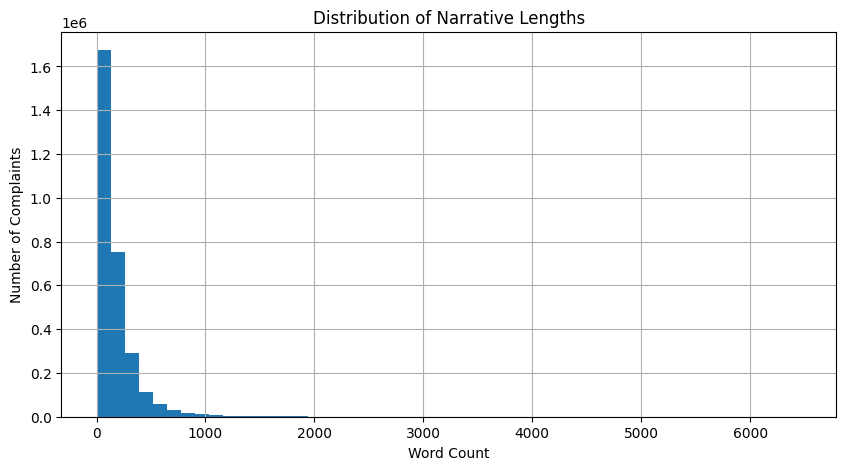

,narrative_length
count,2.980756e+06
mean,1.755976e+02
std,2.259282e+02
min,1.000000e+00
25%,5.900000e+01
50%,1.140000e+02
75%,2.090000e+02
max,6.469000e+03


In [10]:
# Calculate word count for each narrative
df['narrative_length'] = df['Consumer complaint narrative'].dropna().apply(lambda x: len(str(x).split()))

# Plot distribution
plt.figure(figsize=(10,5))
df['narrative_length'].hist(bins=50)
plt.title('Distribution of Narrative Lengths')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.show()

# Show stats
df['narrative_length'].describe()

## Complaints With/Without Narratives

Count and visualize complaints with and without narratives.

With narrative: 2980756
Without narrative: 6629041


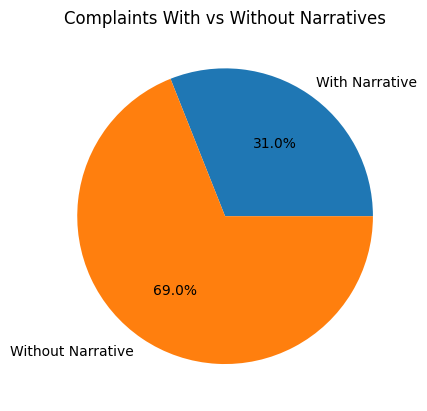

In [11]:
with_narrative = df['Consumer complaint narrative'].notnull().sum()
without_narrative = df['Consumer complaint narrative'].isnull().sum()
print(f"With narrative: {with_narrative}")
print(f"Without narrative: {without_narrative}")

plt.pie([with_narrative, without_narrative], labels=['With Narrative', 'Without Narrative'], autopct='%1.1f%%')
plt.title('Complaints With vs Without Narratives')
plt.show()

## Filter Dataset for Project Requirements

Keep only the five specified products and remove records with empty narratives.

In [16]:
# Define products of interest
products_of_interest = {
    'Credit card': 'Credit card',
    'Payday loan, title loan, or personal loan': 'Personal loan',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal loan',
    'Checking or savings account': 'Savings account',
    'Money transfers': 'Money transfer',
    'Money transfer, virtual currency, or money service': 'Money transfer'
}

# Filter for these products and non-empty narratives
filtered_df = df[
    df['Product'].isin(products_of_interest) &
    df['Consumer complaint narrative'].notnull() &
    (df['Consumer complaint narrative'].str.strip() != '')
].copy()

filtered_df['Product'] = filtered_df['Product'].map(products_of_interest)
print(f"Filtered dataset shape: {filtered_df.shape}")
filtered_df['Product'].value_counts()

Filtered dataset shape: (345805, 19)


,count
Product,
Savings account,140319
Money transfer,98685
Credit card,80667
Personal loan,26134


## Data Cleaning Function

Define a function to clean narratives by removing boilerplate, PII, artifacts, and stopwords, and by normalizing text.

In [17]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Boilerplate phrases, custom stopwords, and artifacts from EDA
boilerplate_phrases = [
    "see the attached documents. i want the bureau to start",
    "my information was heisted and this accounts are fraudulent and",
    "it is indeed ridiculous to see late payments recorded on",
    "i, xxxx xxxx, as a federally protected consumer and per",
    "please update my account and remove the inaccurate late payment.",
    "i am requesting your help to investigate such accounts from",
    "i affirm that the inclusion of incorrectly reported late payment",
    "i need your assistance in reviewing accounts from companies that",
    "it is completely unfair to find late payments on my",
    "i was shocked when i reviewed my credit report and",
    "i have consistently made on-time payments for these accounts, and",
    "the contrast between my consistent on-time payments for this account",
    "it is absurd that i have consistently made timely payments",
    "the distress stemming from this situation is tangible, affecting my",
    "i never been late with this accounts, and please update",
    "i assert that adding inaccurate late payment remarks to my",
    "i've consistently upheld timely payments on this account without any",
    "i've consistently maintained timely payments on this account and have",
    "i've consistently made payments on time for this account, and"
]
custom_stopwords = [
    'xxxx', 'account', 'credit', 'card', 'bank', 'payment', 'customer', 'complaint', 'report', 'company', 'issue'
]
artifacts = ['n/a', 'see attached', 'not applicable', 'none']

def clean_narrative(
    text,
    boilerplate_phrases=boilerplate_phrases,
    remove_pii=True,
    remove_stopwords=True,
    custom_stopwords=custom_stopwords,
    lemmatize=True,
    min_words=5,
    max_words=500,
    artifacts=artifacts
):
    if pd.isnull(text):
        return ""
    text = text.lower()
    for phrase in boilerplate_phrases:
        if text.startswith(phrase):
            text = text[len(phrase):].strip()
    for artifact in artifacts:
        text = text.replace(artifact, "")
    if remove_pii:
        text = re.sub(r'\b\d{10,}\b', '[ACCOUNT/PHONE]', text)
        text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '[EMAIL]', text)
        text = re.sub(r'\b\d{3}[-.\s]??\d{3}[-.\s]??\d{4}\b', '[PHONE]', text)
        text = re.sub(r'xxxx', '[REDACTED]', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.update([w.lower() for w in custom_stopwords])
        text = ' '.join([word for word in text.split() if word not in stop_words])
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    word_count = len(text.split())
    if word_count < min_words or word_count > max_words:
        return ""
    return text

## Apply Cleaning and Inspect Results

Clean the narratives and remove rows with empty cleaned narratives.

In [20]:
filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_narrative)
filtered_df = filtered_df[filtered_df['cleaned_narrative'].str.strip() != ""]
filtered_df[['Consumer complaint narrative', 'cleaned_narrative']].head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,opened name fraudster received notice opened n...
12532,I made the mistake of using my wellsfargo debi...,made mistake using wellsfargo debit depsit fun...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb secured citibank changed unsecured c...
13506,I have a Citi rewards cards. The credit balanc...,citi reward card balance issued recently moved...
13955,b'I am writing to dispute the following charge...,bi writing dispute following charge citi accou...


## Save Cleaned Data

Export the cleaned and filtered dataset for downstream use.

In [22]:
filtered_df.to_csv('../data/processed_dataset/filtered_complaints.csv', index=False)
print("Cleaned data saved to ../data/processed_dataset/filtered_complaints.csv")

Cleaned data saved to ../data/processed_dataset/filtered_complaints.csv


## 📊 Exploratory Data Analysis and Preprocessing

To build a reliable RAG-based chatbot, we first explored and prepared the CFPB complaint dataset. The original dataset contained over **9.6 million records**, but only about **3 million complaints included a narrative** — the free-text portion where customers describe their experiences in detail.

We focused on four key financial products aligned with CrediTrust’s business:
- **Credit card**
- **Personal loan**
- **Savings account**
- **Money transfer**

Using actual product labels from the dataset, we filtered and remapped them to standardized categories. After cleaning and filtering, we retained:

- **Savings account**: 140,319 complaints  
- **Money transfer**: 98,685 complaints  
- **Credit card**: 80,667 complaints  
- **Personal loan**: 26,134 complaints  

---

### Narrative Length Analysis

We calculated word counts for each narrative to assess content richness. The average complaint length was **176 words**, with a median of **114 words**, and some narratives reaching over 6,000 words. To ensure quality and avoid irrelevant entries, we kept only those between **5 and 500 words**.

---

### Preprocessing Strategy

We applied thorough preprocessing to make the text suitable for embedding and retrieval in the RAG pipeline. This included:

- Lowercasing text  
- Removing boilerplate phrases and filler language  
- Redacting personal information (emails, phone numbers, account numbers)  
- Removing special characters and custom stopwords  
- Lemmatizing words for normalization  
- Filtering based on narrative length  

---

### Output

The final cleaned dataset was saved as:  
**`../data/processed_dataset/filtered_complaints.csv`**



In [23]:
%cd /content/creditrust-rag-chatbot/

/content/creditrust-rag-chatbot


In [25]:
# !ssh-keygen -t ed25519 -C "milkidida131@gmail.com" -f ~/.ssh/id_ed25519 -N ""

In [26]:
!mkdir -p ~/.ssh
!eval "$(ssh-agent -s)" && ssh-add ~/.ssh/id_ed25519

Agent pid 13037
Identity added: /root/.ssh/id_ed25519 (milkidida131@gmail.com)


In [27]:
!mkdir -p ~/.ssh && ssh-keyscan github.com >> ~/.ssh/known_hosts

# github.com:22 SSH-2.0-44082949
# github.com:22 SSH-2.0-44082949
# github.com:22 SSH-2.0-44082949
# github.com:22 SSH-2.0-44082949
# github.com:22 SSH-2.0-44082949


In [29]:
!cat ~/.ssh/id_ed25519.pub

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIHUUBGjgf1qtX7tiCUD+OwvDURBFe/uZl9RQjkW4hNGm milkidida131@gmail.com


In [31]:
!git remote set-url origin git@github.com:milki93/creditrust-rag-chatbot.git

In [54]:
!cp "/content/drive/MyDrive/Colab Notebooks/Week 6/EDA_and_preprocessing.ipynb" /content/creditrust-rag-chatbot/notebooks/

In [56]:
# !git config --global user.email ""
# !git config --global user.name ""

In [57]:
# !git checkout -b task-1